In [192]:
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from linearmodels.iv import compare
from linearmodels.panel.results import compare
import statsmodels.api as sm
from statsmodels.api import qqplot
from linearmodels.panel import PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as scipy_stats

import pyreadstat as prs
import pygwalker as pyg

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import json

from tqdm.notebook import tqdm
from itables import init_notebook_mode
# init_notebook_mode()

In [193]:
book_colors = {
    'primary': '#2E86AB',    # Steel blue - main data
    'secondary': '#A23B72',  # Magenta - secondary data
    'accent': '#F18F01',     # Orangxe - highlights/warnings
    'success': '#C73E1D',    # Red-orange - thresholds/targets
    'muted': '#6C757D',      # Gray - reference lines
    'light_gray': '#E5E5E5', # Light gray - backgrounds
    'dark_gray': '#4D4D4D'   # Dark gray - text
}

def setup_book_style():
    """Apply consistent styling to matplotlib plots"""
    plt.rcParams.update({
        'figure.figsize': (10, 7),
        'figure.dpi': 100,
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.titleweight': 'bold',
        'axes.labelsize': 14,
        'axes.labelcolor': '#4D4D4D',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.color': '#E5E5E5',
        'legend.fontsize': 11,
        'legend.frameon': False,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    })

setup_book_style()

In [194]:
def plot_event_margins(model, measure_unit = 'RUB'):
    coef_names = [col for col in model.params.index if col.startswith('rel_period')]
    coefs = model.params[coef_names]
    std_errors = model.std_errors[coef_names]
    
    # Parse relative periods from coefficient names
    rel_periods = [int(name.split('_')[2]) for name in coef_names]
    
    # Create DataFrame for plotting
    coef_df = pd.DataFrame({
        'relative_period': rel_periods,
        'estimate': coefs.values,
        'std_error': std_errors.values
    })
    
    # Add reference period (k = -1) with zero effect
    ref_row = pd.DataFrame({
        'relative_period': [-1],
        'estimate': [0],
        'std_error': [0]
    })
    coef_df = pd.concat([coef_df, ref_row], ignore_index=True)
    coef_df = coef_df.sort_values('relative_period').reset_index(drop=True)
    
    # Calculate confidence intervals (95%)
    coef_df['ci_lower'] = coef_df['estimate'] - 1.96 * coef_df['std_error']
    coef_df['ci_upper'] = coef_df['estimate'] + 1.96 * coef_df['std_error']
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Shade pre-treatment region
    ax.axvspan(-6.5, -0.5, alpha=0.15, color=book_colors['light_gray'], zorder=0)
    
    # Reference lines
    ax.axhline(y=0, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)
    ax.axvline(x=-0.5, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)

    ax.axvline(x=-1, linestyle='--', color='red', linewidth=1, alpha=0.8)
    ax.axvline(x=1, linestyle='--', color='red', linewidth=1, alpha=0.8)

    # ax.annotate('pandemic restrictions\nperiod of interest',
    #             xy=(0, coef_df['ci_upper'].min() * 0.5),
    #             fontsize=10, color='red', ha='center', style='italic')
    
    # Error bars
    ax.errorbar(
        coef_df['relative_period'],
        coef_df['estimate'],
        yerr=[coef_df['estimate'] - coef_df['ci_lower'],
              coef_df['ci_upper'] - coef_df['estimate']],
        fmt='o',
        color=book_colors['primary'],
        markersize=8,
        capsize=4,
        capthick=1.5,
        linewidth=1.5,
        ecolor=book_colors['primary'],
        zorder=3
    )
    
    # Annotations
    ax.annotate('Pre-pandemic',
                xy=(-3.5, coef_df['ci_upper'].max() * 0.6),
                fontsize=10, color=book_colors['muted'], ha='center', style='italic')
    
    ax.annotate('Post-pandemic',
                xy=(2.5, coef_df['ci_upper'].max() * 0.95),
                fontsize=10, color=book_colors['primary'], ha='center', style='italic')
    
    # Labels and title
    ax.set_xlabel('Periods', fontsize=14, color=book_colors['dark_gray'])
    ax.set_ylabel(f'Estimated effect ({measure_unit})', fontsize=14, color=book_colors['dark_gray'])
    ax.set_title('Effect of covid-19 restrictions on NEI',
                 fontsize=16, fontweight='bold', color='#333333', pad=15)
    
    # Subtitle
    ax.text(0.5, 1.02, 'Reference period: k = -1 (one period before treatment)',
            transform=ax.transAxes, fontsize=11, color='grey', ha='center')
    
    # Caption (takeaway)
    fig.text(0.1, -0.02,
             'Takeaway: No significant pre-trends; effect peaks at k=1, then gradually declines.',
             fontsize=9, color='grey', ha='left')
    
    ax.set_xticks(range(-6, 4))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.show()

In [195]:
def wald_test_for_period_insignificance(event_study_model_reduced):
    pre_treatment_terms = [t for t in event_study_terms if int(t.split('_')[2]) < -1]
    pre_coefs = event_study_model_reduced.params[pre_treatment_terms].values
    pre_vcov = event_study_model_reduced.cov.loc[pre_treatment_terms, pre_treatment_terms].values

    q = len(pre_treatment_terms)
    wald_stat = pre_coefs @ np.linalg.inv(pre_vcov) @ pre_coefs / q
    df_resid = event_study_model_reduced.nobs - event_study_model_reduced.params.shape[0]
    p_value = 1 - scipy_stats.f.cdf(wald_stat, q, df_resid)
    
    print(f"\nJoint F-test for pre-treatment coefficients:")
    print(f"  F({q}, {df_resid}) = {wald_stat:.4f}")
    print(f"  p-value = {p_value:.4f}")

In [196]:
def visualize(var):
    return (
    panel
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col(var).mean())
).plot.line(x='year', y=var, color='has_disablity')

In [197]:
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(X.shape[1])]
    return vif_data

# goals
* income model
* wages model
* benefit model
* psm ++ all above with psm

In [216]:
panel = pl.read_parquet('../data/wages_working_data2.parquet')
# panel = panel.filter(
#     pl.col('total_income') < 100_000
# )
panel = (
    panel
    .with_columns(gender = pl.when(pl.col('gender') == 'MALE').then(1).otherwise(0))
    .with_columns(recieves_pension = pl.when(pl.col('recieves_pension') == 'Yes').then(1).otherwise(0))
    .with_columns(recieves_pension_30days = pl.when(pl.col('recieves_pension_30days') == 'Yes').then(1).otherwise(0))
    .with_columns(income_decrease_bc_covid = pl.when(pl.col('income_decrease_bc_covid') == 'Yes').then(1).otherwise(0))

    .with_columns(harmfull_job = pl.when(pl.col('harmfull_job') == 'Yes').then(1).otherwise(0))
        
    .with_columns(pl.col('disability_class').str.replace(' ', '_').str.to_lowercase())
    .to_dummies('disability_class', drop_nulls=True, drop_first=True)
    .with_columns(has_disability = pl.when(pl.col('has_disability') == 'Yes').then(1).otherwise(0))
    .with_columns(male_retiered = pl.when(
        (pl.col('gender') == 1) & (pl.col('age') >= 65)
    ).then(1).otherwise(0))
    .with_columns(female_retiered = pl.when(
        (pl.col('gender') == 0) & (pl.col('age') >= 60)
    ).then(1).otherwise(0))
    .with_columns(is_retired = pl.col('male_retiered') + pl.col('female_retiered'))
    .to_dummies('educ_level', drop_nulls=True).drop('educ_level_common')
    .with_columns(has_disability_period = pl.col('has_disability') + pl.col('period'))
    .with_columns(has_disability_common_period = pl.col('has_disability_common') + pl.col('period'))
)
panel

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class_first_group,disability_class_second_group,disability_class_third_group,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,inwgt,is_employed,has_disablity,wages,period,educ_level_higher,educ_level_school_or_less,educ_level_university,is_married,period_relevance,is_town,is_female,has_disability_common,male_retiered,female_retiered,is_retired,has_disability_period,has_disability_common_period
f64,f64,i32,i32,f64,f64,f64,f64,f64,f64,i32,str,i32,i32,i32,i32,u8,u8,u8,i32,f64,str,f64,str,str,str,f64,str,str,i32,i32,f64,i32,i32,f64,i32,u8,u8,u8,i64,i64,i64,i32,i32,i32,i32,i32,i32,i32
60.0,2019.0,0,0,0.0,0.0,18000.0,0.0,18000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""November""",4.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",51.0,"""10 and more grades of school &…","""In a registered marriage""",0,0,0.950363,1,0,18000.0,0,1,0,0,1,-1,1,1,0,0,0,0,0,0
60.0,2020.0,0,0,0.0,0.0,30000.0,0.0,30000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""September""",30.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",52.0,"""10 and more grades of school &…","""In a registered marriage""",0,1,0.942376,1,0,30000.0,1,1,0,0,1,0,1,1,0,0,0,0,1,1
60.0,2022.0,1,1,11000.0,0.0,23000.0,0.0,12000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""November""",12.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",54.0,"""10 and more grades of school &…","""In a registered marriage""",0,1,0.888277,1,0,12000.0,0,1,0,0,1,2,1,1,0,0,0,0,0,0
125.0,2015.0,0,0,0.0,0.0,20000.0,0.0,20000.0,0.0,0,"""You are currently working""",0,0,1,0,0,0,0,0,null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",52.0,"""Secondary School Diploma""","""In a registered marriage""",0,0,0.896978,1,0,20000.0,0,0,0,0,1,-5,0,1,0,0,0,0,0,0
125.0,2017.0,1,1,13300.0,0.0,49300.0,0.0,36000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""September""",23.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",54.0,"""Secondary School Diploma""","""In a registered marriage""",0,0,0.850216,1,0,36000.0,0,0,0,0,1,-3,0,1,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59277.0,2019.0,0,0,0.0,0.0,40000.0,0.0,40000.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""November""",21.0,"""Moscow City""","""oblastnoy center""","""Moscow City""",32.5,"""Institute, University, Academy…","""Never married""",0,0,1.146114,1,0,40000.0,0,0,0,1,0,-1,1,1,0,0,0,0,0,0
59277.0,2020.0,0,0,0.0,0.0,40000.0,0.0,40000.0,0.0,1,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""September""",12.0,"""Moscow City""","""oblastnoy center""","""Moscow City""",33.5,"""Institute, University, Academy…","""Never married""",0,0,1.129374,1,0,40000.0,1,0,0,1,0,0,1,1,0,0,0,0,1,1
59277.0,2024.0,0,0,0.0,0.0,80000.0,0.0,0.0,0.0,0,"""You are currently working""",0,0,0,0,0,0,0,0,null,"""November""",1.0,"""Moscow City""","""oblastnoy center""","""Moscow City""",37.5,"""Institute, University, Academy…","""Never married""",0,0,1.101734,1,0,0.0,0,0,0,1,0,4,1,1,0,0,0,0,0,0


In [217]:
panel['age'].describe()

statistic,value
str,f64
"""count""",14920.0
"""null_count""",0.0
"""mean""",42.192627
"""std""",12.156685
"""min""",18.0
"""25%""",33.0
"""50%""",41.0
"""75%""",51.0
"""max""",91.5


In [218]:
panel.write_parquet('../data/wages_working_data3.parquet')

# incomes visualizations

In [219]:
visualize('total_income')

alt.Chart(...)

In [220]:
visualize('amount_pension')

alt.Chart(...)

In [221]:
visualize('amount_unemp_benefits')

alt.Chart(...)

In [222]:
visualize('wage_j1')

alt.Chart(...)

In [223]:
visualize('wage_j2')

alt.Chart(...)

In [224]:
visualize('iea_income')

alt.Chart(...)

In [225]:
visualize('wages')

alt.Chart(...)

# plotting wages differences

In [281]:
df_wages = (
    panel
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity'])
        .agg(
            pl.col('wages').mean()
            #(pl.sum(pl.col('wages') * pl.col('inwgt')) / pl.sum(pl.col('inwgt'))).alias('wages_weighted')
        )
    .to_pandas()
)
df_wages['has_disablity'] = df_wages['has_disablity'].map({0: 'No', 1: 'Yes'})
df_wages = df_wages.pivot(index='year', columns='has_disablity', values='wages')
df_wages

has_disablity,No,Yes
year,,
2015-01-01,21401.619410,24000.000000
2016-01-01,22330.419228,18386.956522
2017-01-01,24404.519347,20316.000000
2018-01-01,26365.545703,21120.000000
2019-01-01,29226.652593,23279.283019
2020-01-01,29917.337919,22620.000000
2021-01-01,33133.805714,24545.294118
2022-01-01,35486.390684,27372.608696
2023-01-01,41147.748518,32496.969697


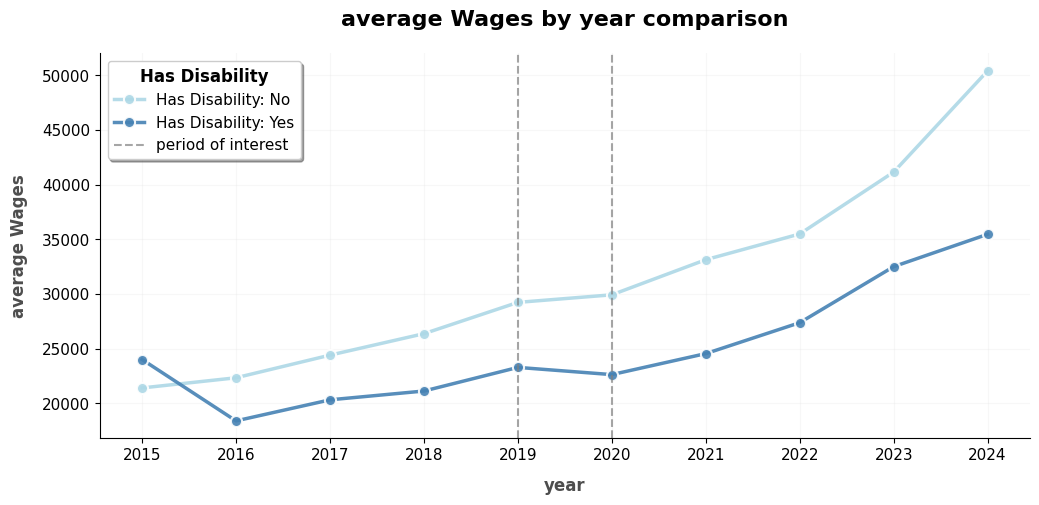

In [287]:
colors = {'Yes': 'steelblue', 'No': 'lightblue'}  # Red for Yes, Green for No
fig, ax = plt.subplots(figsize=(12, 5))
# Plot each disability category with custom styling
for column in df_wages.columns:
    ax.plot(df_wages.index, df_wages[column], 
            marker='o', 
            linewidth=2.5,
            markersize=8,
            color=colors.get(column, '#3498db'),
            label=f'Has Disability: {column}',
            markeredgecolor='white',
            markeredgewidth=1.5,
            alpha=0.9)

# Customize the plot with premium styling
ax.set_title(f'average Wages by year comparison', 
             fontsize=16, 
             fontweight='bold', 
             pad=20,
             #fontfamily='serif'
            )
ax.axvline(x=pd.Timestamp('2019-01-01'), 
           color='gray', 
           linestyle='--', 
           linewidth=1.5, 
           label='period of interest',
           alpha=0.7)  # Optional label

ax.axvline(x=pd.Timestamp('2020-01-01'), 
           color='gray', 
           linestyle='--', 
           linewidth=1.5, 
           alpha=0.7)
ax.set_xlabel('year', fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel(f'average Wages', fontsize=12, fontweight='semibold', labelpad=10)

legend = ax.legend(title='Has Disability',
                  title_fontsize=12,
                  fontsize=11,
                  loc='best',
                  frameon=True,
                  fancybox=True,
                  shadow=True,
                  edgecolor='#cccccc',
                  facecolor='white')
legend.get_title().set_fontweight('bold')

plt.savefig('../notebooks/agerage_wages_comparison.png')

<Axes: xlabel='year', ylabel='wages'>

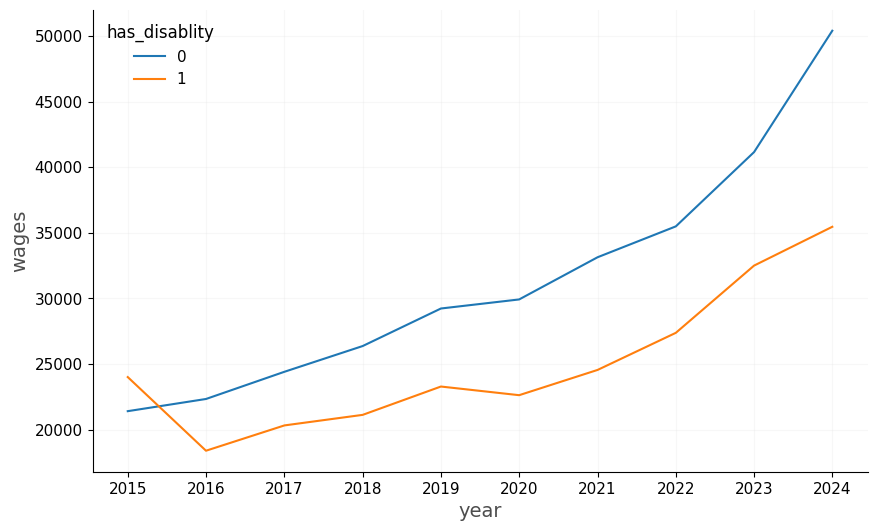

In [252]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_wages, x='year', y='wages', hue='has_disablity')

In [226]:
panel_2019_2020 = (
    panel
    .filter(
        pl.col('year').is_in([2020, 2019])
    )
    .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas().set_index(['idind', 'year'])
panel_2019_2020

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                    
60.0    2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
125.0   2019-01-01                 1                        1         15000.0   
        2020-01-01                 1                        1         16000.0   
126.0   2019-01-01                 0                        0             0.0   
...                              ...                      ...             ...   
59275.0 2020-01-01                 0                        0             0.0   
59277.0 2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
59285.0 2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   

                    iea_income  total_income  amount_unemp_benefits   wage_j1  \
idind   year                                                                    
60.0    2019-01-01         0.0       18000.0                    0.0   18000.0   
        2020-01-01         0.0       30000.0                    0.0   30000.0   
125.0   2019-01-01         0.0       35000.0                    0.0   20000.0   
        2020-01-01         0.0       45500.0                    0.0   29500.0   
126.0   2019-01-01         0.0       20000.0                    0.0   20000.0   
...                        ...           ...                    ...       ...   
59275.0 2020-01-01         0.0       27000.0                    0.0   27000.0   
59277.0 2019-01-01         0.0       40000.0                    0.0   40000.0   
        2020-01-01         0.0       40000.0                    0.0   40000.0   
59285.0 2019-01-01         0.0      130000.0                    0.0  130000.0   
        2020-01-01         0.0      135000.0                    0.0  135000.0   

                    wage_j2  income_decrease_bc_covid  \
idind   year                                            
60.0    2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
125.0   2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
126.0   2019-01-01      0.0                         0   
...                     ...                       ...   
59275.0 2020-01-01      0.0                         1   
59277.0 2019-01-01      0.0                         0   
        2020-01-01      0.0                         1   
59285.0 2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   

                                  work_status  ...  is_married  \
idind   year                                   ...               
60.0    2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   
125.0   2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   
126.0   2019-01-01  You are currently working  ...           1   
...                                       ...  ...         ...   
59275.0 2020-01-01  You are currently working  ...           0   
59277.0 2019-01-01  You are currently working  ...           0   
        2020-01-01  You are currently working  ...           0   
59285.0 2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   

                    period_relevance  is_town  is_female  \
idind   year                                               
60.0    2019-01-01                -1        1          1   
        2020-01-01                 0        1          1   
125.0   2019-01-01                -1        0          1   
        202

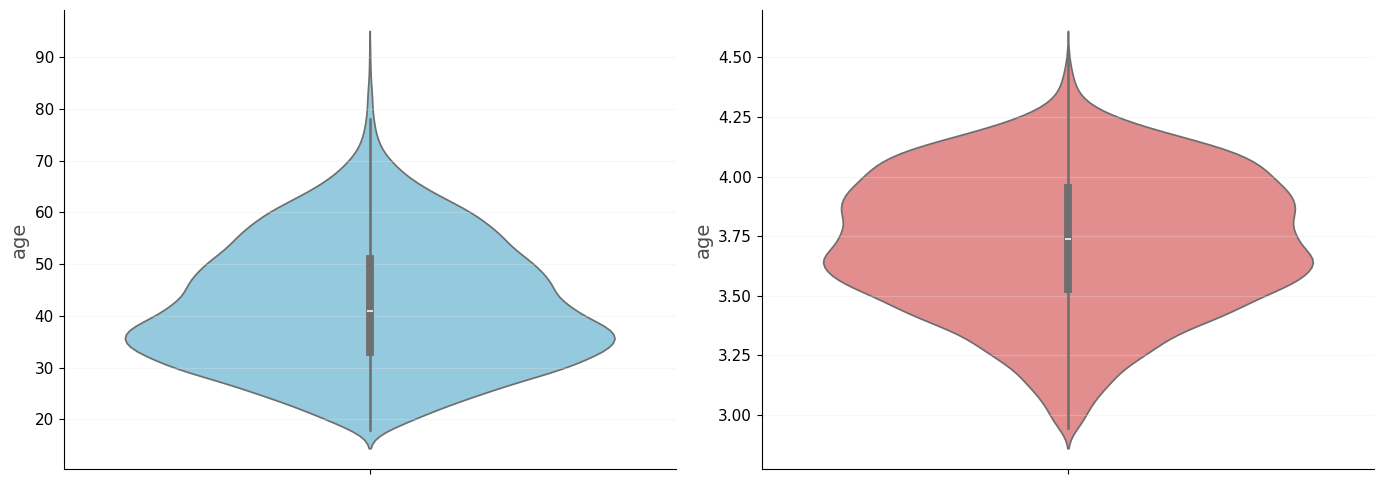

In [227]:
wages_original = panel['age'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

# income model

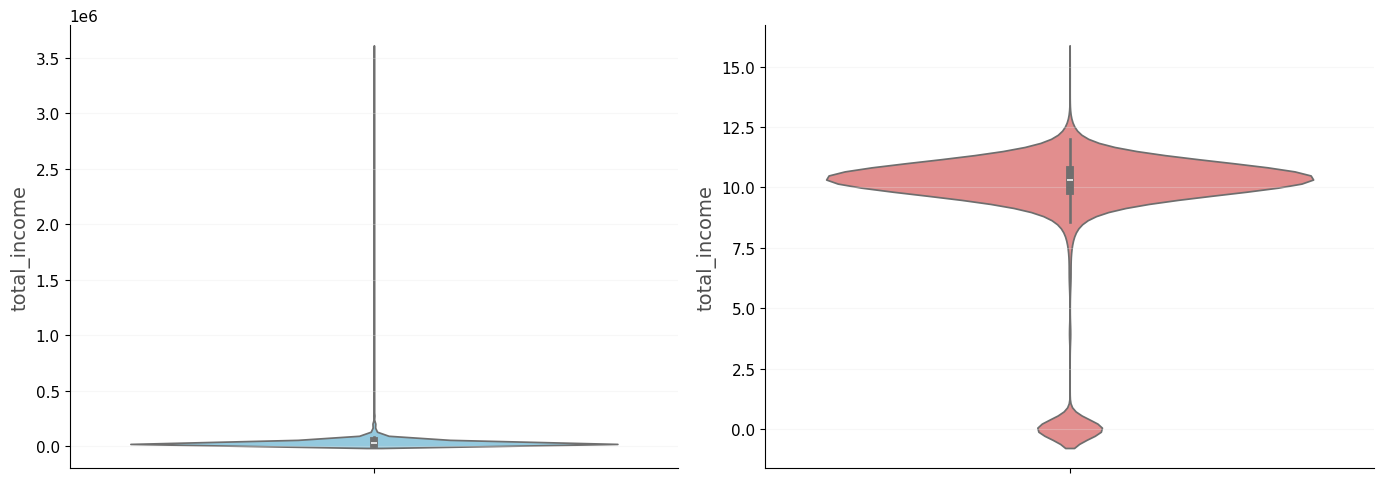

In [228]:
wages_original = panel['total_income'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

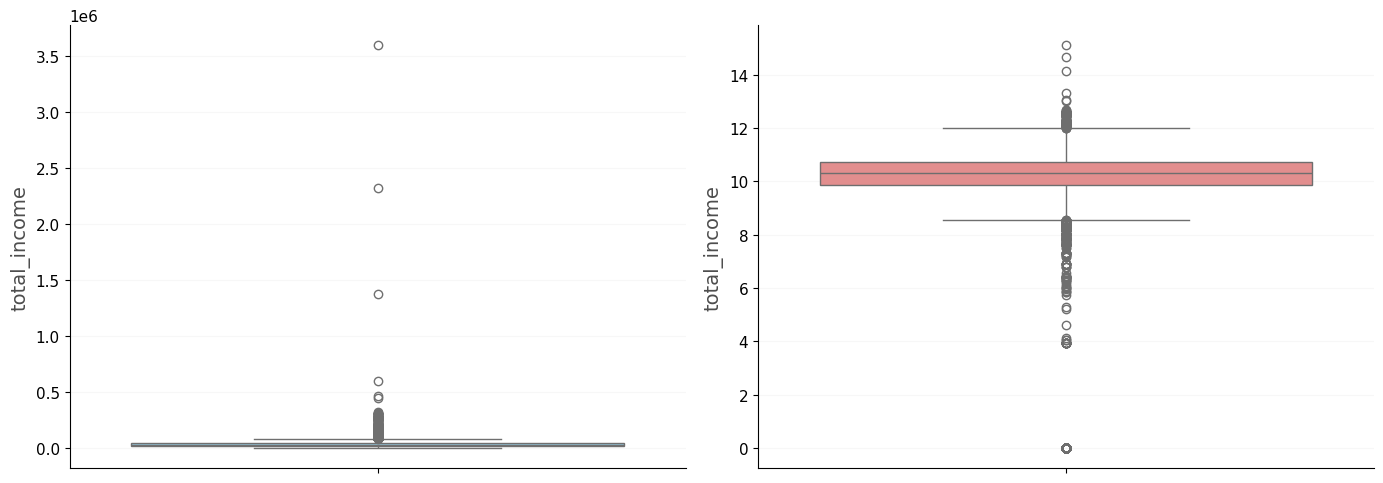

In [229]:
wages_original = panel['total_income'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.boxplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [230]:
model1 = PanelOLS.from_formula('total_income ~ I(has_disablity * period) + EntityEffects', data=panel_2019_2020).fit()#.fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           total_income   R-squared:                     2.099e-07
Estimator:                   PanelOLS   R-squared (Between):           5.728e-05
No. Observations:                4772   R-squared (Within):            2.099e-07
Date:                Wed, May 06 2026   R-squared (Overall):           4.442e-05
Time:                        09:04:55   Log-likelihood                -5.527e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      0.0005
Entities:                        2386   P-value                           0.9821
Avg Obs:                       2.0000   Distribution:                  F(1,2385)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             0.0005
                            

In [231]:
model2 = PanelOLS.from_formula('np.log1p(total_income) ~ I(has_disablity * period) + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model2.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     np.log1p(total_income)   R-squared:                     4.789e-07
Estimator:                       PanelOLS   R-squared (Between):          -3.082e-05
No. Observations:                    4772   R-squared (Within):            4.789e-07
Date:                    Wed, May 06 2026   R-squared (Overall):          -3.021e-05
Time:                            09:04:56   Log-likelihood                   -8355.9
Cov. Estimator:                 Clustered                                           
                                            F-statistic:                      0.0011
Entities:                            2386   P-value                           0.9730
Avg Obs:                           2.0000   Distribution:                  F(1,2385)
Min Obs:                           2.0000                                           
Max Obs:                           2.0000   F-statistic (robust):

In [233]:
panel_2014_2024 = (
    panel
        #.filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        #.filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(
            (pl.col('period_relevance') > -5) & (pl.col('period_relevance') < 5)
        )
        # .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas()
panel_2014_2024_dta = panel_2014_2024.set_index(['idind', 'year'])
panel_2014_2024_dta

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                    
60.0    2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
        2022-01-01                 1                        1         11000.0   
125.0   2017-01-01                 1                        1         13300.0   
        2019-01-01                 1                        1         15000.0   
...                              ...                      ...             ...   
59277.0 2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
        2024-01-01                 0                        0             0.0   
59285.0 2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   

                    iea_income  total_income  amount_unemp_benefits   wage_j1  \
idind   year                                                                    
60.0    2019-01-01         0.0       18000.0                    0.0   18000.0   
        2020-01-01         0.0       30000.0                    0.0   30000.0   
        2022-01-01         0.0       23000.0                    0.0   12000.0   
125.0   2017-01-01         0.0       49300.0                    0.0   36000.0   
        2019-01-01         0.0       35000.0                    0.0   20000.0   
...                        ...           ...                    ...       ...   
59277.0 2019-01-01         0.0       40000.0                    0.0   40000.0   
        2020-01-01         0.0       40000.0                    0.0   40000.0   
        2024-01-01         0.0       80000.0                    0.0       0.0   
59285.0 2019-01-01         0.0      130000.0                    0.0  130000.0   
        2020-01-01         0.0      135000.0                    0.0  135000.0   

                    wage_j2  income_decrease_bc_covid  \
idind   year                                            
60.0    2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
        2022-01-01      0.0                         0   
125.0   2017-01-01      0.0                         0   
        2019-01-01      0.0                         0   
...                     ...                       ...   
59277.0 2019-01-01      0.0                         0   
        2020-01-01      0.0                         1   
        2024-01-01      0.0                         0   
59285.0 2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   

                                  work_status  ...  is_married  \
idind   year                                   ...               
60.0    2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   
        2022-01-01  You are currently working  ...           1   
125.0   2017-01-01  You are currently working  ...           1   
        2019-01-01  You are currently working  ...           1   
...                                       ...  ...         ...   
59277.0 2019-01-01  You are currently working  ...           0   
        2020-01-01  You are currently working  ...           0   
        2024-01-01  You are currently working  ...           0   
59285.0 2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   

                    period_relevance  is_town  is_female  \
idind   year                                               
60.0    2019-01-01                -1        1          1   
        2020-01-01                 0        1          1   
        2022-01-01                 2        1          1   
125.0   201

In [234]:
event_study_terms = []
for p in sorted(panel_2014_2024_dta['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024_dta['period_relevance'].values == p) & (panel_2014_2024_dta['has_disability_period'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_2014_2024_dta['total_income']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, check_rank=True).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:           total_income   R-squared:                        0.0036
Estimator:                   PanelOLS   R-squared (Between):              0.0025
No. Observations:               13851   R-squared (Within):               0.0036
Date:                Wed, May 06 2026   R-squared (Overall):              0.0033
Time:                        09:05:51   Log-likelihood                -1.663e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.1696
Entities:                        2386   P-value                           0.0000
Avg Obs:                       5.8051   Distribution:                 F(8,11457)
Min Obs:                       2.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             2.6940
                            

In [235]:
print(calculate_vif(X_event))

                 feature  VIF
0  rel_period_-4_treated  1.0
1  rel_period_-3_treated  1.0
2  rel_period_-2_treated  1.0
3  rel_period_-1_treated  1.0
4   rel_period_1_treated  1.0
5   rel_period_2_treated  1.0
6   rel_period_3_treated  1.0
7   rel_period_4_treated  1.0


# wages model

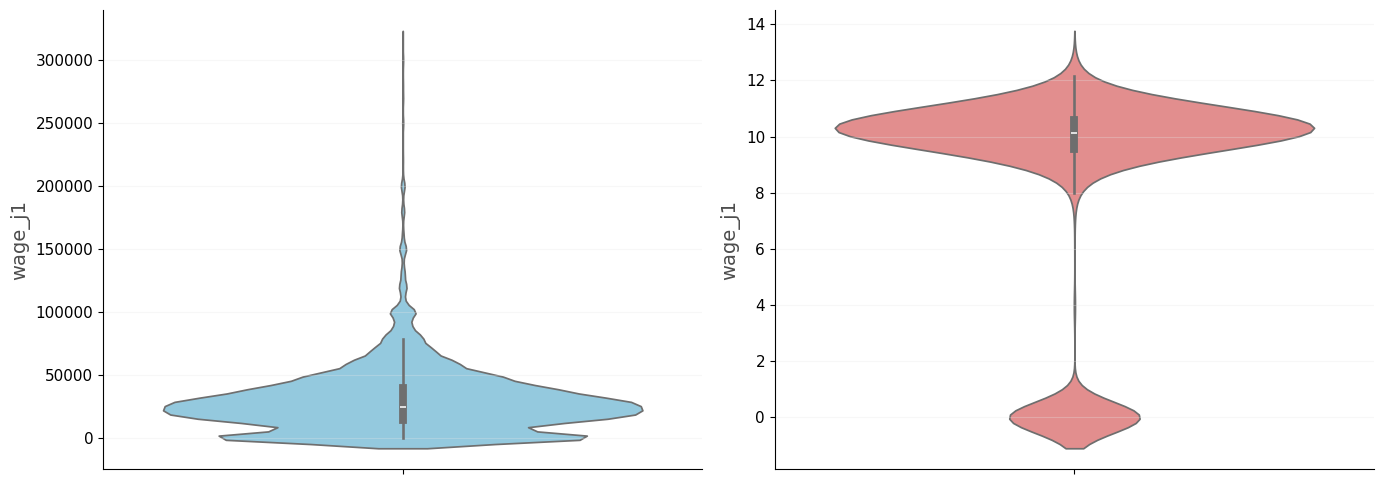

In [236]:
wages_original = panel['wage_j1'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

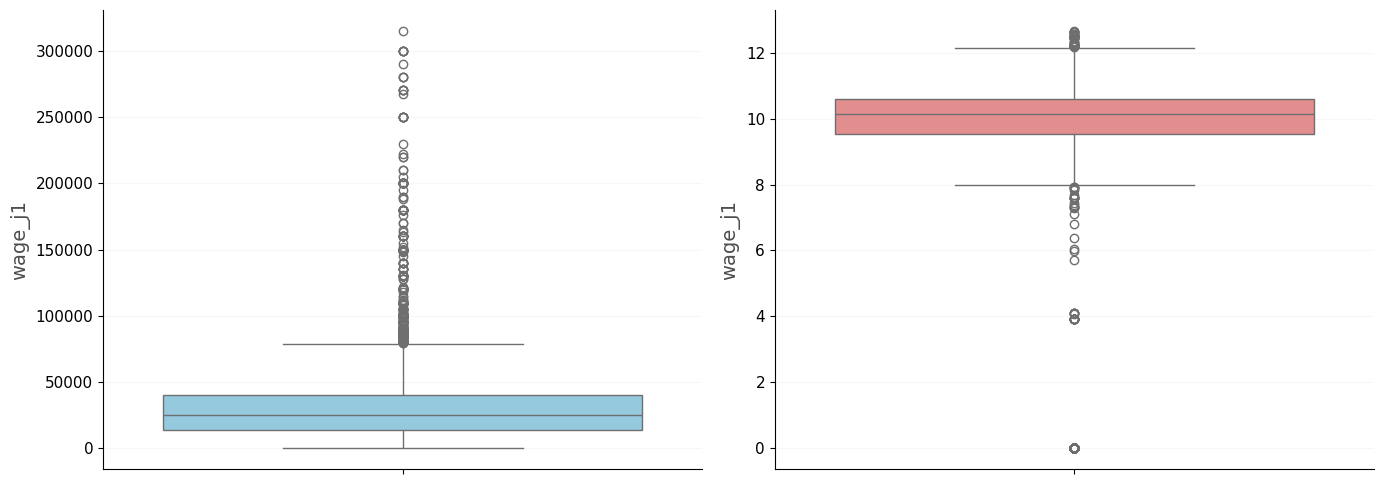

In [237]:
wages_original = panel['wage_j1'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.boxplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [238]:
model3 = PanelOLS.from_formula('wage_j1 ~ has_disability_period + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                wage_j1   R-squared:                        0.0029
Estimator:                   PanelOLS   R-squared (Between):              0.0246
No. Observations:                4772   R-squared (Within):               0.0029
Date:                Wed, May 06 2026   R-squared (Overall):              0.0231
Time:                        09:06:14   Log-likelihood                -5.053e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.0168
Entities:                        2386   P-value                           0.0081
Avg Obs:                       2.0000   Distribution:                  F(1,2385)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             7.0080
                            

In [239]:
-1.088e+04

-10880.0

In [240]:
model4 = PanelOLS.from_formula('np.log1p(wage_j1) ~ has_disability_period + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      np.log1p(wage_j1)   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):             -0.0185
No. Observations:                4772   R-squared (Within):               0.0016
Date:                Wed, May 06 2026   R-squared (Overall):             -0.0175
Time:                        09:06:23   Log-likelihood                -1.036e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.9290
Entities:                        2386   P-value                           0.0476
Avg Obs:                       2.0000   Distribution:                  F(1,2385)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             3.8852
                            

In [241]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['has_disability_period'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_2014_2024_dta['wage_j1']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, time_effects=False, check_rank=False).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:                wage_j1   R-squared:                       -2.7695
Estimator:                   PanelOLS   R-squared (Between):             -2.1322
No. Observations:               13851   R-squared (Within):              -0.1614
Date:                Wed, May 06 2026   R-squared (Overall):             -1.3297
Time:                        09:06:38   Log-likelihood                -1.645e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                     -1202.6
Entities:                        2386   P-value                           1.0000
Avg Obs:                       5.8051   Distribution:                 F(7,11458)
Min Obs:                       2.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             10.362
                            

# benefit model

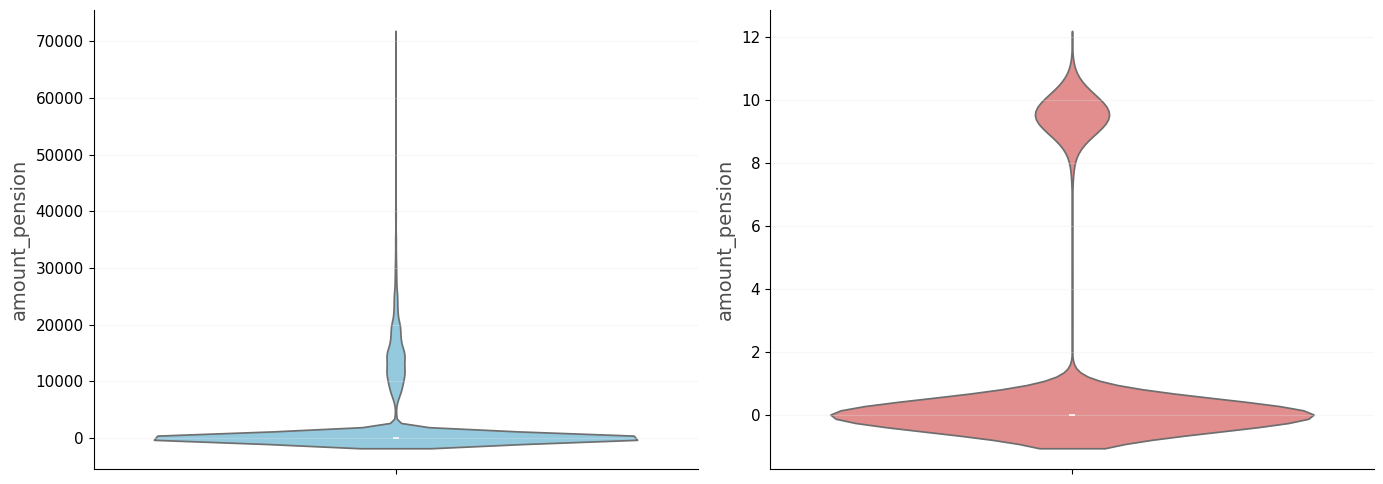

In [232]:
wages_original = panel['amount_pension'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

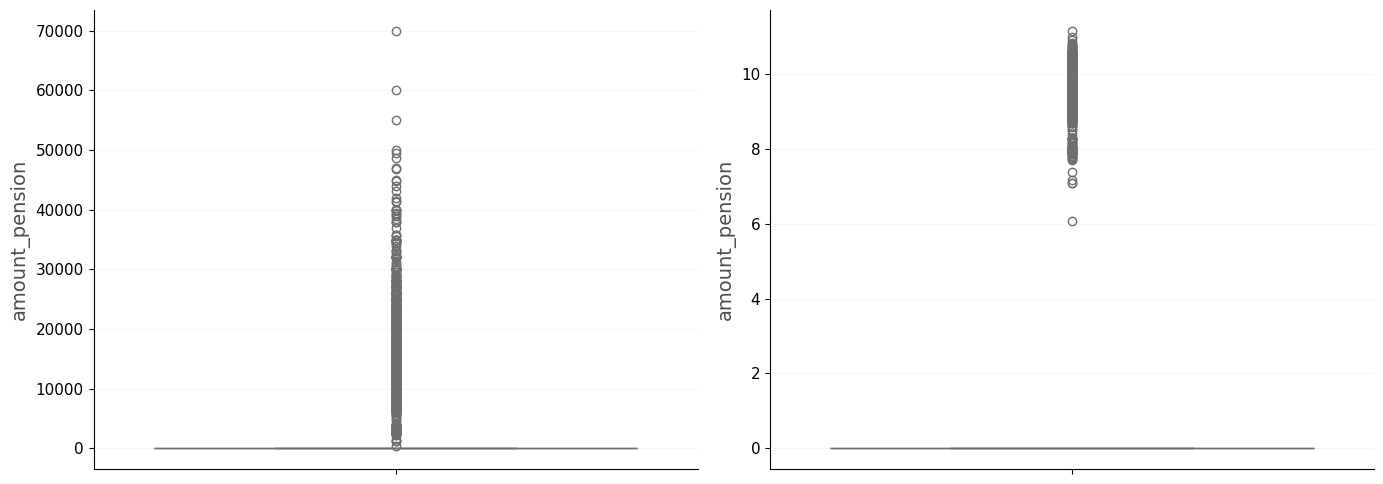

In [233]:
wages_original = panel['amount_pension'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.boxplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [234]:
model5 = PanelOLS.from_formula('amount_pension ~ has_disablity + EntityEffects', data=panel_2019_2020).fit()#.fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model5.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         amount_pension   R-squared:                        0.0367
Estimator:                   PanelOLS   R-squared (Between):              0.0567
No. Observations:                3682   R-squared (Within):               0.0367
Date:                Wed, Apr 29 2026   R-squared (Overall):              0.0572
Time:                        16:46:39   Log-likelihood                -3.075e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      52.939
Entities:                        2293   P-value                           0.0000
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             52.939
                            

In [235]:
model6 = PanelOLS.from_formula('np.log1p(amount_pension) ~ has_disablity + EntityEffects', data=panel_2019_2020).fit()#.fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model6.summary)

                             PanelOLS Estimation Summary                              
Dep. Variable:     np.log1p(amount_pension)   R-squared:                        0.0660
Estimator:                         PanelOLS   R-squared (Between):              0.0770
No. Observations:                      3682   R-squared (Within):               0.0660
Date:                      Wed, Apr 29 2026   R-squared (Overall):              0.0814
Time:                              16:46:39   Log-likelihood                   -3177.7
Cov. Estimator:                  Unadjusted                                           
                                              F-statistic:                      98.072
Entities:                              2293   P-value                           0.0000
Avg Obs:                             1.6058   Distribution:                  F(1,1388)
Min Obs:                             1.0000                                           
Max Obs:                             2.0000

In [ ]:
print(model6.summary)

In [236]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['has_disability'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_2014_2024_dta['amount_pension']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, time_effects=False, check_rank=False).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:         amount_pension   R-squared:                       -0.9943
Estimator:                   PanelOLS   R-squared (Between):             -0.0933
No. Observations:               12451   R-squared (Within):              -0.0374
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0785
Time:                        16:46:40   Log-likelihood                -1.173e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                     -721.63
Entities:                        2312   P-value                           1.0000
Avg Obs:                       5.3854   Distribution:                 F(7,10132)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             16.772
                            

In [237]:
print(compare({
    'model 1':model1, 
    "model 1 log": model2, 
    "model 2": model3, 
    'model 2 log':model4,
    "model 3": model5, 
    'model 3 log':model6
}, stars=True))

                                                                     Model Comparison                                                                     
                                 model 1                model 1 log          model 2           model 2 log            model 3                  model 3 log
----------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable               total_income     np.log1p(total_income)          wage_j1     np.log1p(wage_j1)     amount_pension     np.log1p(amount_pension)
Estimator                       PanelOLS                   PanelOLS         PanelOLS              PanelOLS           PanelOLS                     PanelOLS
No. Observations                    3682                       3682             3682                  3682               3682                         3682
Cov. Est.                     Unadjusted                  Clustered   

# PSM

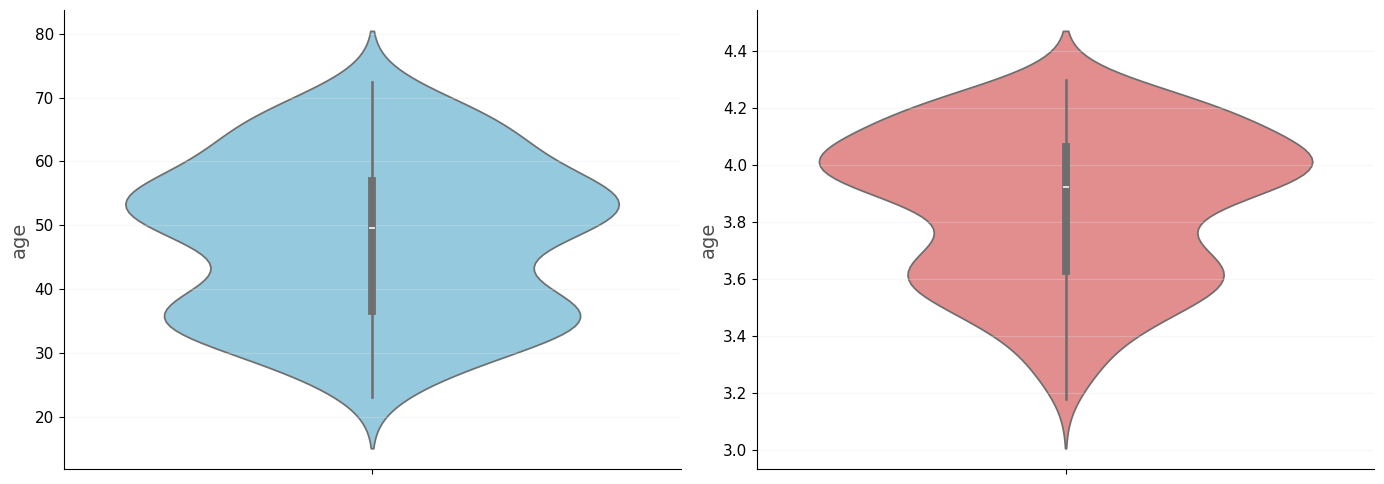

In [255]:
wages_original = panel.filter(pl.col('has_disablity') == 1)['age'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

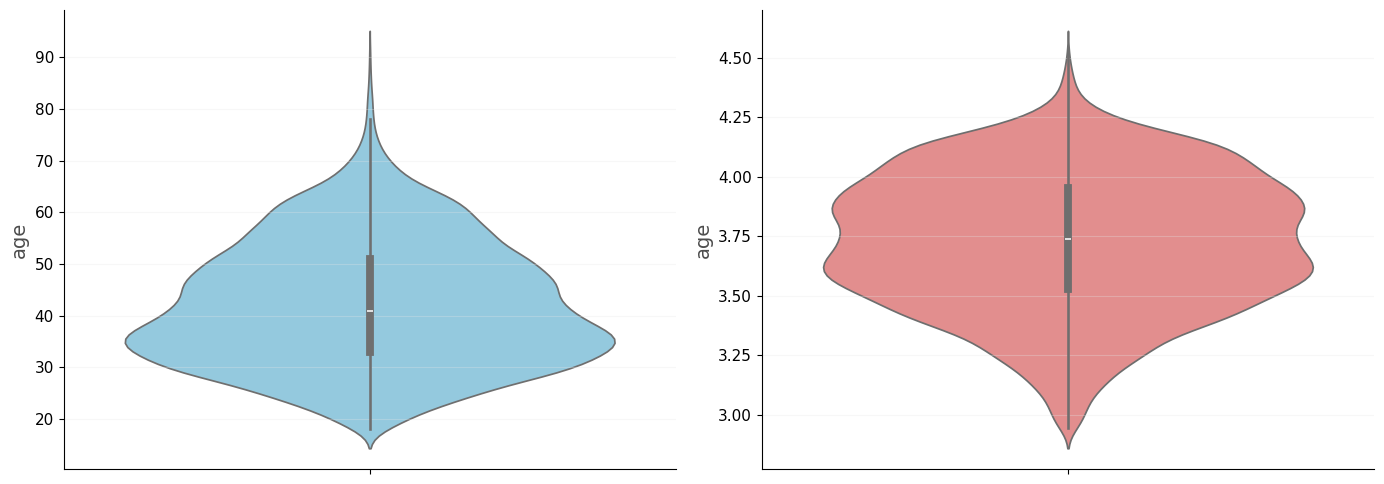

In [256]:
wages_original = panel.filter(pl.col('has_disablity') == 0)['age'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

# Pension models

In [242]:
panel_2019_2020

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                    
60.0    2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
125.0   2019-01-01                 1                        1         15000.0   
        2020-01-01                 1                        1         16000.0   
126.0   2019-01-01                 0                        0             0.0   
...                              ...                      ...             ...   
59275.0 2020-01-01                 0                        0             0.0   
59277.0 2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   
59285.0 2019-01-01                 0                        0             0.0   
        2020-01-01                 0                        0             0.0   

                    iea_income  total_income  amount_unemp_benefits   wage_j1  \
idind   year                                                                    
60.0    2019-01-01         0.0       18000.0                    0.0   18000.0   
        2020-01-01         0.0       30000.0                    0.0   30000.0   
125.0   2019-01-01         0.0       35000.0                    0.0   20000.0   
        2020-01-01         0.0       45500.0                    0.0   29500.0   
126.0   2019-01-01         0.0       20000.0                    0.0   20000.0   
...                        ...           ...                    ...       ...   
59275.0 2020-01-01         0.0       27000.0                    0.0   27000.0   
59277.0 2019-01-01         0.0       40000.0                    0.0   40000.0   
        2020-01-01         0.0       40000.0                    0.0   40000.0   
59285.0 2019-01-01         0.0      130000.0                    0.0  130000.0   
        2020-01-01         0.0      135000.0                    0.0  135000.0   

                    wage_j2  income_decrease_bc_covid  \
idind   year                                            
60.0    2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
125.0   2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   
126.0   2019-01-01      0.0                         0   
...                     ...                       ...   
59275.0 2020-01-01      0.0                         1   
59277.0 2019-01-01      0.0                         0   
        2020-01-01      0.0                         1   
59285.0 2019-01-01      0.0                         0   
        2020-01-01      0.0                         0   

                                  work_status  ...  is_married  \
idind   year                                   ...               
60.0    2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   
125.0   2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   
126.0   2019-01-01  You are currently working  ...           1   
...                                       ...  ...         ...   
59275.0 2020-01-01  You are currently working  ...           0   
59277.0 2019-01-01  You are currently working  ...           0   
        2020-01-01  You are currently working  ...           0   
59285.0 2019-01-01  You are currently working  ...           1   
        2020-01-01  You are currently working  ...           1   

                    period_relevance  is_town  is_female  \
idind   year                                               
60.0    2019-01-01                -1        1          1   
        2020-01-01                 0        1          1   
125.0   2019-01-01                -1        0          1   
        202

In [239]:
model7 = PanelOLS.from_formula('np.log1p(wages) ~ has_disablity + is_retired + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model7.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        np.log1p(wages)   R-squared:                        0.0061
Estimator:                   PanelOLS   R-squared (Between):             -0.0363
No. Observations:                3682   R-squared (Within):               0.0061
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0358
Time:                        16:46:45   Log-likelihood                   -7423.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.2435
Entities:                        2293   P-value                           0.0145
Avg Obs:                       1.6058   Distribution:                  F(2,1387)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             3.9658
                            

In [240]:
model7 = PanelOLS.from_formula('np.log1p(wages) ~ has_disablity + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model7.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        np.log1p(wages)   R-squared:                        0.0049
Estimator:                   PanelOLS   R-squared (Between):             -0.0169
No. Observations:                3682   R-squared (Within):               0.0049
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0171
Time:                        16:46:46   Log-likelihood                   -7426.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.7748
Entities:                        2293   P-value                           0.0093
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.0610
                            

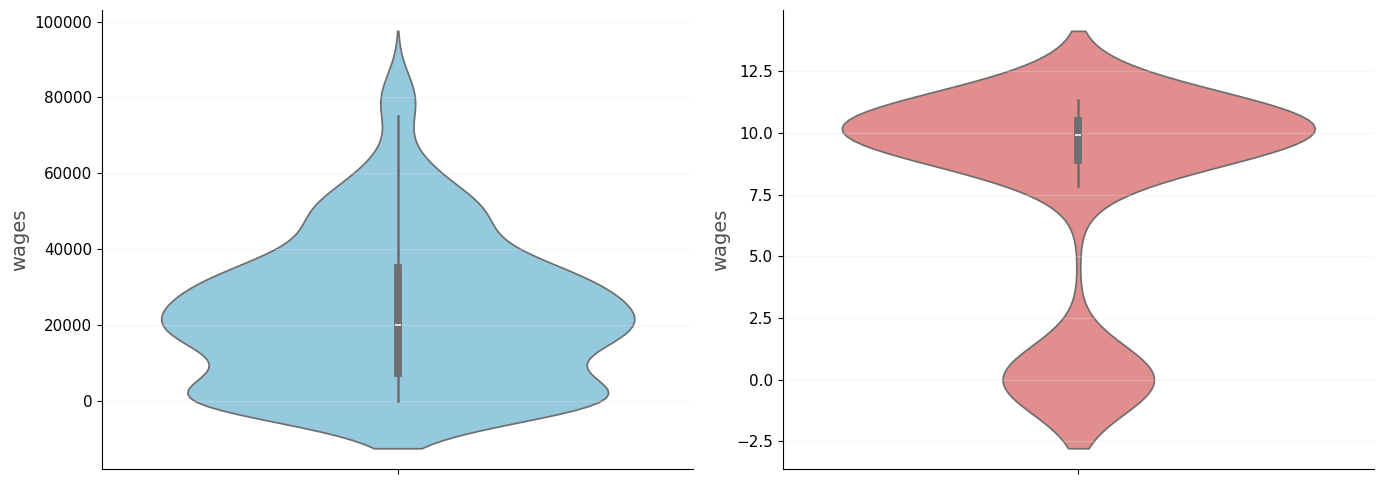

In [241]:
wages_original = panel.filter(pl.col('has_disablity') == 1)['wages'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

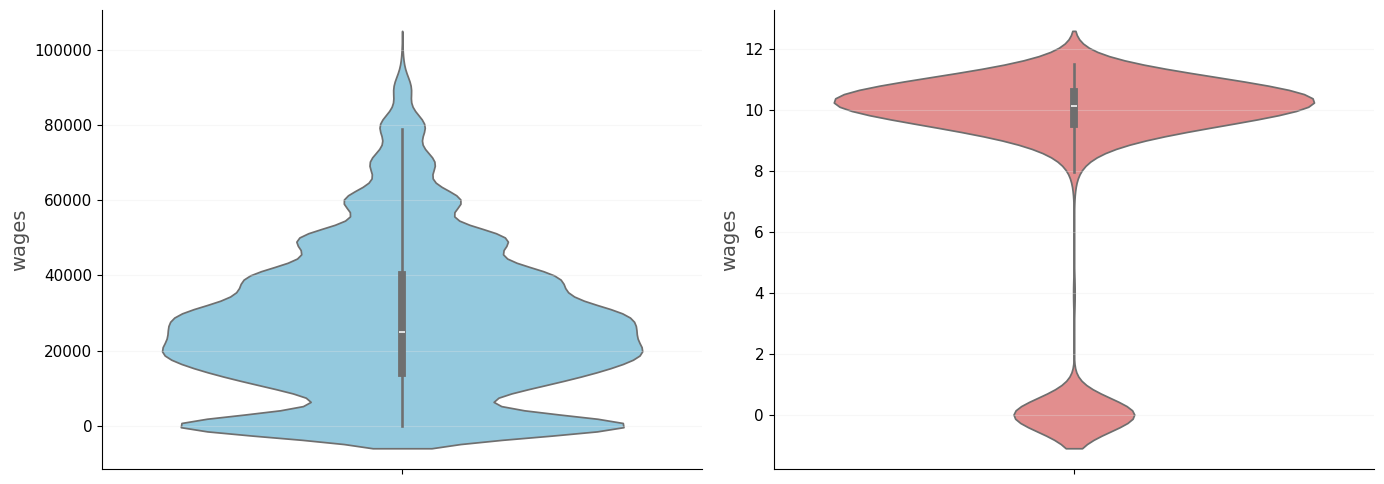

In [242]:
wages_original = panel.filter(pl.col('has_disablity') == 0)['wages'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [243]:
model8 = PanelOLS.from_formula('wages ~ has_disability_period + EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model8.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0010
Estimator:                   PanelOLS   R-squared (Between):              0.0147
No. Observations:                4772   R-squared (Within):               0.0010
Date:                Wed, May 06 2026   R-squared (Overall):              0.0137
Time:                        09:21:03   Log-likelihood                -5.068e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.4513
Entities:                        2386   P-value                           0.1176
Avg Obs:                       2.0000   Distribution:                  F(1,2385)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             2.4504
                            

In [257]:
print(model8.summary.as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &       wages        & \textbf{  R-squared:         }   &      0.0029      \\
\textbf{Estimator:}        &      PanelOLS      & \textbf{  R-squared (Between):}  &     -0.0120      \\
\textbf{No. Observations:} &        3682        & \textbf{  R-squared (Within):}   &      0.0029      \\
\textbf{Date:}             &  Wed, Apr 29 2026  & \textbf{  R-squared (Overall):}  &     -0.0117      \\
\textbf{Time:}             &      16:46:48      & \textbf{  Log-likelihood     }   &    -3.764e+04    \\
\textbf{Cov. Estimator:}   &     Clustered      & \textbf{                     }   &                  \\
\textbf{}                  &                    & \textbf{  F-statistic:       }   &      4.0112      \\
\textbf{Entities:}         &        2293        & \textbf{  P-value            }   &      0.0454      \\
\textbf{Avg Obs:}          &       1.6058       & \textbf{  Distribution:      }   &    F(1,1388)     \\
\textbf{M

In [244]:
model9 = PanelOLS.from_formula('wages ~ has_disablity + is_retired +  EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model9.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0038
Estimator:                   PanelOLS   R-squared (Between):             -0.0241
No. Observations:                3682   R-squared (Within):               0.0038
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0234
Time:                        16:46:48   Log-likelihood                -3.764e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.6791
Entities:                        2293   P-value                           0.0690
Avg Obs:                       1.6058   Distribution:                  F(2,1387)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.1020
                            

In [245]:
model10 = PanelOLS.from_formula('wages ~ has_disablity +  EntityEffects', data=panel_2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model10.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0029
Estimator:                   PanelOLS   R-squared (Between):             -0.0120
No. Observations:                3682   R-squared (Within):               0.0029
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.0117
Time:                        16:46:49   Log-likelihood                -3.764e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.0112
Entities:                        2293   P-value                           0.0454
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.9824
                            

In [246]:
did_data.columns

Index(['idind', 'year', 'recieves_pension', 'recieves_pension_30days',
       'amount_pension', 'iea_income', 'total_income', 'amount_unemp_benefits',
       'wage_j1', 'wage_j2', 'income_decrease_bc_covid', 'work_status',
       'hearing_disability', 'eye_disability', 'spinal_disability',
       'neuro_disability', 'disability_class_first_group',
       'disability_class_second_group', 'disability_class_third_group',
       'has_disability', 'registred_as_disabled', 'month', 'wave', 'region',
       'habitat', 'psu', 'age', 'educ', 'marst', 'gender', 'is_employed',
       'has_disablity', 'wages', 'educ_level', 'is_married',
       'period_relevance', 'is_town', 'is_female', 'has_disability_common',
       'male_retiered', 'female_retiered', 'is_retired', 'period'],
      dtype='object')

In [247]:
did_data = panel_2019_2020.reset_index()
did_data['period'] = np.where(did_data['year'] == '2020-01-01', 1, 0)
did_data

,idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,...,educ_level_university,is_married,period_relevance,is_town,is_female,has_disability_common,male_retiered,female_retiered,is_retired,period
0,29.0,2020-01-01,0,0,0.0,0.0,43000.0,0.0,43000.0,0.0,...,0,0,1,1,1,0,0,0,0,1
1,180.0,2020-01-01,0,0,0.0,0.0,32000.0,0.0,25000.0,7000.0,...,1,1,1,0,1,0,0,0,0,1
2,434.0,2019-01-01,0,0,0.0,0.0,25000.0,0.0,25000.0,0.0,...,1,1,0,1,1,0,0,0,0,0
3,434.0,2020-01-01,0,0,0.0,0.0,20000.0,0.0,10000.0,0.0,...,1,1,1,1,1,0,0,0,0,1
4,454.0,2020-01-01,0,0,0.0,0.0,40500.0,0.0,10500.0,0.0,...,1,1,1,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3677,60464.0,2020-01-01,0,0,0.0,0.0,22000.0,0.0,22000.0,0.0,...,0,1,1,1,0,0,0,0,0,1
3678,60465.0,2020-01-01,1,1,13500.0,0.0,33500.0,0.0,20000.0,0.0,...,0,1,1,1,1,0,0,0,0,1
3679,60467.0,2020-01-01,0,0,0.0,0.0,26600.0,0.0,26000.0,0.0,...,1,0,1,1,1,0,0,0,0,1
3680,60473.0,2020-01-01,0,0,0.0,0.0,40000.0,0.0,40000.0,0.0,...,0,1,1,1,1,0,0,0,0,1


In [254]:
did_model = smf.ols('wages ~ has_disability * period', did_data).fit(cov_type='HC2')
print(did_model.summary2())

                        Results: Ordinary least squares
Model:                   OLS                  Adj. R-squared:         0.000     
Dependent Variable:      wages                AIC:                    82584.1108
Date:                    2026-04-29 16:49     BIC:                    82608.9557
No. Observations:        3682                 Log-Likelihood:         -41288.   
Df Model:                3                    F-statistic:            1.666     
Df Residuals:            3678                 Prob (F-statistic):     0.172     
R-squared:               0.001                Scale:                  3.2204e+08
--------------------------------------------------------------------------------
                        Coef.     Std.Err.    z    P>|z|     [0.025     0.975]  
--------------------------------------------------------------------------------
Intercept             27033.3678  496.4549 54.4528 0.0000  26060.3341 28006.4014
has_disability        -5380.0344 3097.4000 -1.7370 0.

In [16]:
panel_psm = pd.read_parquet('../data/wages_working_data_psm_full.parquet')#.set_index(['idind', 'year'])
panel_psm

,idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,...,is_town,is_female,has_disability_common,male_retiered,female_retiered,is_retired,log_age,distance,weights,subclass
0,29.0,2017.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,3.850148,0.040605,47.611511,101
1,29.0,2020.0,0,0,0.0,0.0,43000.0,0.0,43000.0,0.0,...,1,1,0,0,0,0,3.912023,0.021036,47.611511,51
2,29.0,2021.0,1,1,11300.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,3.931826,0.021702,47.611511,52
3,180.0,2015.0,0,0,0.0,3000.0,21000.0,0.0,10000.0,8000.0,...,0,1,0,0,0,0,3.676301,0.011401,47.611511,104
4,180.0,2020.0,0,0,0.0,0.0,32000.0,0.0,25000.0,7000.0,...,0,1,0,0,0,0,3.795489,0.011011,47.611511,103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13509,60467.0,2022.0,0,0,0.0,0.0,38000.0,0.0,37000.0,0.0,...,1,1,0,0,0,0,3.871201,0.015832,47.611511,93
13510,60473.0,2020.0,0,0,0.0,0.0,40000.0,0.0,40000.0,0.0,...,1,1,0,0,0,0,3.860730,0.015459,47.611511,178
13511,60473.0,2021.0,0,0,0.0,0.0,55000.0,0.0,35000.0,0.0,...,1,1,0,0,0,0,3.881564,0.015999,47.611511,7
13512,60474.0,2020.0,1,1,15600.0,0.0,15600.0,0.0,0.0,0.0,...,1,0,0,0,0,0,3.828641,0.026890,47.611511,41


In [17]:
panel_psm_dta = panel_psm.set_index(['idind', 'year'])
panel_psm_dta

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                
29.0    2017.0                 0                        0             0.0   
        2020.0                 0                        0             0.0   
        2021.0                 1                        1         11300.0   
180.0   2015.0                 0                        0             0.0   
        2020.0                 0                        0             0.0   
...                          ...                      ...             ...   
60467.0 2022.0                 0                        0             0.0   
60473.0 2020.0                 0                        0             0.0   
        2021.0                 0                        0             0.0   
60474.0 2020.0                 1                        1         15600.0   
        2021.0                 1                        1         16200.0   

                iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                               
29.0    2017.0         0.0           0.0                    0.0      0.0   
        2020.0         0.0       43000.0                    0.0  43000.0   
        2021.0         0.0           0.0                    0.0      0.0   
180.0   2015.0      3000.0       21000.0                    0.0  10000.0   
        2020.0         0.0       32000.0                    0.0  25000.0   
...                    ...           ...                    ...      ...   
60467.0 2022.0         0.0       38000.0                    0.0  37000.0   
60473.0 2020.0         0.0       40000.0                    0.0  40000.0   
        2021.0         0.0       55000.0                    0.0  35000.0   
60474.0 2020.0         0.0       15600.0                    0.0      0.0   
        2021.0         0.0       31200.0                    0.0  14000.0   

                wage_j2  income_decrease_bc_covid                work_status  \
idind   year                                                                   
29.0    2017.0      0.0                         0        You are not working   
        2020.0      0.0                         1  You are currently working   
        2021.0      0.0                         0  You are currently working   
180.0   2015.0   8000.0                         0  You are currently working   
        2020.0   7000.0                         0  You are currently working   
...                 ...                       ...                        ...   
60467.0 2022.0      0.0                         0  You are currently working   
60473.0 2020.0      0.0                         1  You are currently working   
        2021.0      0.0                         0  You are currently working   
60474.0 2020.0      0.0                         0  You are currently working   
        2021.0      0.0                         0  You are currently working   

                ...  is_town  is_female  has_disability_common  male_retiered  \
idind   year    ...                                                             
29.0    2017.0  ...        1          1                      0              0   
        2020.0  ...        1          1                      0              0   
        2021.0  ...        1          1                      0              0   
180.0   2015.0  ...        0          1                      0              0   
        2020.0  ...        0          1                      0              0   
...             ...      ...        ...                    ...            ...   
60467.0 2022.0  ...        1          1                      0              0   
60473.0 2020.0  ...        1          1                      0              0   
        2021.0  ...        1          1                      0              0   
60474.0 2020.0  ...        1          0                      0              0   
        2021

In [13]:
panel_psm_1920 = pd.read_parquet('../data/wages_working_data_psm_full.parquet')
panel_psm_1920 = panel_psm_1920[panel_psm_1920['year'].isin([2019, 2020])]
panel_psm_1920 = panel_psm_1920.set_index(['idind', 'year'])
panel_psm_1920

recieves_pension  recieves_pension_30days  amount_pension  \
idind   year                                                                
29.0    2020.0                 0                        0             0.0   
180.0   2020.0                 0                        0             0.0   
434.0   2019.0                 0                        0             0.0   
        2020.0                 0                        0             0.0   
454.0   2020.0                 0                        0             0.0   
...                          ...                      ...             ...   
60464.0 2020.0                 0                        0             0.0   
60465.0 2020.0                 1                        1         13500.0   
60467.0 2020.0                 0                        0             0.0   
60473.0 2020.0                 0                        0             0.0   
60474.0 2020.0                 1                        1         15600.0   

                iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                               
29.0    2020.0         0.0       43000.0                    0.0  43000.0   
180.0   2020.0         0.0       32000.0                    0.0  25000.0   
434.0   2019.0         0.0       25000.0                    0.0  25000.0   
        2020.0         0.0       20000.0                    0.0  10000.0   
454.0   2020.0         0.0       40500.0                    0.0  10500.0   
...                    ...           ...                    ...      ...   
60464.0 2020.0         0.0       22000.0                    0.0  22000.0   
60465.0 2020.0         0.0       33500.0                    0.0  20000.0   
60467.0 2020.0         0.0       26600.0                    0.0  26000.0   
60473.0 2020.0         0.0       40000.0                    0.0  40000.0   
60474.0 2020.0         0.0       15600.0                    0.0      0.0   

                wage_j2  income_decrease_bc_covid  \
idind   year                                        
29.0    2020.0      0.0                         1   
180.0   2020.0   7000.0                         0   
434.0   2019.0      0.0                         0   
        2020.0      0.0                         0   
454.0   2020.0      0.0                         0   
...                 ...                       ...   
60464.0 2020.0      0.0                         0   
60465.0 2020.0      0.0                         0   
60467.0 2020.0      0.0                         0   
60473.0 2020.0      0.0                         1   
60474.0 2020.0      0.0                         0   

                                                      work_status  ...  \
idind   year                                                       ...   
29.0    2020.0                          You are currently working  ...   
180.0   2020.0                          You are currently working  ...   
434.0   2019.0                          You are currently working  ...   
        2020.0                          You are currently working  ...   
454.0   2020.0  You are on paid leave: maternity leave or taki...  ...   
...                                                           ...  ...   
60464.0 2020.0                          You are currently working  ...   
60465.0 2020.0                          You are currently working  ...   
60467.0 2020.0  You are on paid leave: maternity leave or taki...  ...   
60473.0 2020.0                          You are currently working  ...   
60474.0 2020.0                          You are currently working  ...   

                is_town  is_female  has_disability_common  male_retiered  \
idind   year                                                               
29.0    2020.0        1          1                      0              0   
180.0   2020.0        0          1                      0              0   
434.0   2019.0        1          1                      0           

In [15]:

model11 = PanelOLS.from_formula('wages ~ has_disablity +  EntityEffects', data=panel_psm_1920, weights= panel_psm_1920['weights']).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model11.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0061
Estimator:                   PanelOLS   R-squared (Between):             -0.0181
No. Observations:                3682   R-squared (Within):               0.0061
Date:                Sat, May 02 2026   R-squared (Overall):             -0.0177
Time:                        21:09:44   Log-likelihood                -3.561e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8.4829
Entities:                        2293   P-value                           0.0036
Avg Obs:                       1.6058   Distribution:                  F(1,1388)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             7.2689
                            

In [20]:
event_study_terms = []
for p in sorted(panel_psm['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_psm_dta[col_name] = ((panel_psm['period_relevance'].values == p) & (panel_psm['has_disability'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_psm_dta[event_study_terms + ['weights']]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_psm_dta['amount_pension']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, time_effects=False, check_rank=False, weights=X_event['weights']).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:         amount_pension   R-squared:                        0.0382
Estimator:                   PanelOLS   R-squared (Between):              0.0120
No. Observations:               13514   R-squared (Within):               0.0382
Date:                Sat, May 02 2026   R-squared (Overall):              0.0137
Time:                        21:15:24   Log-likelihood                -1.238e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      44.478
Entities:                        2312   P-value                           0.0000
Avg Obs:                       5.8452   Distribution:                F(10,11192)
Min Obs:                       1.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             8.2806
                            